In [1]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *
from antipode.antipode_mixins import AntipodeTrainingMixin, AntipodeSaveLoadMixin


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [5]:
class ANTIPODE(PyroBaseModuleClass,AntipodeTrainingMixin, AntipodeSaveLoadMixin):
    """
    ANTIPODE (Single Cell Ancestral Node Taxonomy Inference by Parcellation of Differential Expression) 
    leverages variational inference for analyzing and categorizing cell types by accounting for biological and batch covariates and discrete and continuous latent variables. This model works by simultaneously integrating evolution-inspired differential expression parcellation, taxonomy generation (clustering) and batch correction.

    Parameters:
    adata (AnnData): The single-cell dataset encapsulated in an AnnData object.
    discov_pair (tuple): Specifies the discovery covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    batch_pair (tuple): Specifies the batch covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    seccov_key (string):  Specifies the secondary covariate matrix's key in obsm in the AnnData object. Only affects DM.
    layer (str): The specific layer of the AnnData object to be analyzed.
    level_sizes (list of int): Defines the hierarchical model structure (corresponding to a layered tree) by specifying the size of each level. Make sure each layer gets progressively larger and ideally start with a single root. Defaults to [1, 10, 100].
    bi_depth (int): Tree depth (from root) for batch identity effect correction. Defaults to 2. Should be less than length of level_sizes
    psi_levels (list of bool): Whether or not to allow a psi at each level of the layered tree. Should be 1. (all levels) or a list of len(level_sizes)
    
    num_latent (int): The number of latent dimensions to model. Defaults to 50.
    num_batch_embed (int): Number of embedding dimensions for batch effects. Defaults to 10. 
    scale_factor (float, optional): Factor for scaling the data normalization. Inferred from data if None. [DANGER]
    prior_scale (float): Scale for the Laplace prior distributions. Defaults to 100. [DANGER]
    dcd_prior (float, optional): Scale for discov_constitutive_de. Use this for missing genes (set to large negative value and rest 0. Zeros if None.
    use_psi (bool): Whether to utilize psi continuous variation parameter. Defaults to True.
    use_q_score (bool): Whether to use q continuous "quality" scores. Defaults to True.
    dist_normalize (bool): EXPERIMENTAL. Whether to apply distance normalization. Defaults to False.
    z_transform (pytorch function): Function to be applied to latent space (Z) e.g. centered_sigmoid, sigmoid. This will mess up DE Parameter scaling.
    loc_as_param, zdw_as_param, intercept_as_param (bool): Flags for using location, Z decoder weight, and intercept as parameters instead (maximum likelihood inference instead of Laplace MAP), respectively. All default to False.
    theta_prior (float): Initial value for the inverse dispersion of the negative binomial. Defaults to 50. [DANGER]
    scale_init_val (float): Initial value for scaling parameters in phase 1. Defaults to 0.01. [DANGER]
    classifier_hidden, encoder_hidden, batch_embedder_hidden (list of int): Sizes of hidden layers for the classifier, encoder and batch embedding networks, respectively.
    sampler_category (string): Obs categorical column which will be used with the dataloader to sample each category with equal probability. (suggested use is the discov category)
    """

    def __init__(self, adata, discov_pair, batch_pair, layer, seccov_key='seccov_dummy', level_sizes=[1,10,100],
                 num_latent=50,scale_factor=None, prior_scale=100,dcd_prior=None,use_psi=True,sampler_category=None,
                 loc_as_param=True,zdw_as_param=True,intercept_as_param=True,seccov_as_param=True,use_q_score=True,psi_levels=[True],
                 num_batch_embed=10,theta_prior=50.,min_theta=1.,scale_init_val=0.01,bi_depth=2,dist_normalize=False,z_transform=None,
                 classifier_hidden=[3000,3000,3000],encoder_hidden=[6000,5000,3000,1000],batch_embedder_hidden=[1000,500,500]):

        pyro.clear_param_store()
        self.init_args = dict(locals())
        # Determine num_discov and num_batch from the AnnData object
        self.discov_loc, self.discov_key = discov_pair
        self.batch_loc, self.batch_key = batch_pair
        self.seccov_key=seccov_key
        self.num_discov = adata.obsm[self.discov_key].shape[-1] if self.discov_loc == 'obsm' else len(adata.obs[self.discov_key].unique())
        self.num_batch = adata.obsm[self.batch_key].shape[-1] if self.batch_loc == 'obsm' else len(adata.obs[self.batch_key].unique())        
        self.design_matrix = (self.discov_loc == 'obsm')
        self.layer = layer
        self.num_seccov = adata.obsm[self.seccov_key].shape[-1] if self.seccov_key != 'seccov_dummy' else 1
        
        self._setup_adata_manager_store: dict[str, type[scvi.data.AnnDataManager]] = {}
        self.num_var = adata.layers[layer].shape[-1]
        self.num_latent = num_latent
        self.scale_factor = 1.0#scale_factor if scale_factor is not None else 2e2 / (self.num_var * num_particles * num_latent)
        self.num_batch_embed = num_batch_embed
        self.temperature = 0.1
        self.epsilon = 1e-5
        self.approx = False
        self.prior_scale = prior_scale
        self.use_psi = use_psi
        self.use_q_score = use_q_score
        self.loc_as_param = loc_as_param
        self.zdw_as_param = zdw_as_param
        self.seccov_as_param = seccov_as_param
        self.intercept_as_param = intercept_as_param
        self.theta_prior = theta_prior
        self.scale_init_val = scale_init_val
        self.level_sizes = level_sizes
        self.num_labels = sum(level_sizes)
        self.bi_depth = bi_depth
        self.bi_depth = sum(self.level_sizes[:self.bi_depth])
        self.dist_normalize = dist_normalize
        self.sampler_category = sampler_category
        self.psi_levels = [float(x) for x in psi_levels]
        self.min_theta=min_theta

        self.dcd_prior = torch.zeros((self.num_discov,self.num_var)) if dcd_prior is None else dcd_prior#Use this for 
                
        # Initialize plates to be used during sampling
        self.var_plate = pyro.plate('var_plate',self.num_var,dim=-1)
        self.discov_plate = pyro.plate('discov_plate',self.num_discov,dim=-3)
        self.seccov_plate = pyro.plate('seccov_plate',self.num_seccov,dim=-3)
        self.batch_plate = pyro.plate('batch_plate',self.num_batch,dim=-3)
        self.latent_plate = pyro.plate('latent_plate',self.num_latent,dim=-1)
        self.latent_plate2 = pyro.plate('latent_plate2',self.num_latent,dim=-2)
        self.label_plate = pyro.plate('label_plate',self.num_labels,dim=-2)
        self.batch_embed_plate = pyro.plate('batch_embed_plate',self.num_batch_embed,dim=-3)
        self.bi_depth_plate = pyro.plate('bi_depth_plate',self.bi_depth,dim=-2)

        #Initialize MAP inference modules
        self.dm=MAPLaplaceModule(self,'discov_dm',[self.num_discov,self.num_labels,self.num_latent],[self.discov_plate,self.label_plate,self.latent_plate],param_only=True)
        self.sm=MAPLaplaceModule(self,'seccov_dm',[self.num_seccov,self.num_labels,self.num_latent],[self.seccov_plate,self.label_plate,self.latent_plate],param_only=True)
        self.bm=MAPLaplaceModule(self,'batch_dm',[self.num_batch,self.num_labels,self.num_latent],[self.batch_plate,self.label_plate,self.latent_plate],param_only=True)
        self.di=MAPLaplaceModule(self,'discov_di',[self.num_discov,self.num_labels,self.num_var],[self.discov_plate,self.label_plate,self.var_plate],param_only=True)
        self.bei=MAPLaplaceModule(self,'batch_di',[self.num_batch_embed,self.bi_depth,self.num_var],[self.batch_embed_plate,self.bi_depth_plate,self.var_plate],param_only=True)
        self.ci=MAPLaplaceModule(self,'cluster_intercept',[self.num_labels, self.num_var],[self.label_plate,self.var_plate],param_only=True)
        self.dc=MAPLaplaceModule(self,'discov_dc',[self.num_discov,self.num_latent,self.num_var],[self.discov_plate,self.latent_plate2,self.var_plate],param_only=True)
        self.zdw=MAPLaplaceModule(self,'z_decoder_weight',[self.num_latent,self.num_var],[self.latent_plate2,self.var_plate],init_val=((2/self.num_latent)*(torch.rand(self.num_latent,self.num_var)-0.5)),param_only=True)
        self.zl=MAPLaplaceModule(self,'locs',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=True)
        self.zs=MAPHalfCauchyModule(self,'scales',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],init_val=self.scale_init_val*torch.ones(self.num_labels,self.num_latent),constraint=constraints.positive,param_only=True)
        self.zld=MAPLaplaceModule(self,'locs_dynam',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=True)
        self.qg=MAPLaplaceModule(self,'quality_genes',[1,self.num_var],[self.var_plate],param_only=True)
        
        self.tree_edges = TreeEdges(self,straight_through=False)
        self.tree_convergence_bottom_up = TreeConvergenceBottomUp(self)        
        self.z_transform = null_function if z_transform is None else z_transform#centered_sigmoid#torch.special.expit

        if self.design_matrix:
            fields={'s':('layers',self.layer),
            'discov_ind':('obsm',self.discov_key),
            'batch_ind':('obsm',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.float32,"discov_ind":np.float32,'seccov':np.float32}
        else:
            fields={'s':('layers',self.layer),
            'discov_ind':('obs',self.discov_key),
            'batch_ind':('obs',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.int64,"discov_ind":np.int64,'seccov':np.float32}

        self.fields=fields
        self.field_types=field_types
        self.setup_anndata(adata, {'discov_ind': discov_pair, 'batch_ind': batch_pair,'seccov':self.seccov_key}, self.field_types)
        
        super().__init__()
        # Setup the various neural networks used in the model and guide
        self.z_decoder=ZDecoder(num_latent=self.num_latent, num_var=self.num_var)        
        self.zl_encoder=ZLEncoder(num_var=self.num_var,hidden_dims=encoder_hidden,num_cat_input=self.num_discov,
                    outputs=[(self.num_latent,None),(self.num_latent,softplus),(1,None),(1,softplus)])
        
        self.classifier=Classifier(num_latent=self.num_latent,hidden_dims=classifier_hidden,
                    outputs=[(self.num_labels,None),(len(self.level_sizes),None),(len(self.level_sizes),softplus)])

        #Too large to exactly model gene-level batch effects for all cluster x batch
        self.be_nn=SimpleFFNN(in_dim=self.num_batch,hidden_dims=batch_embedder_hidden,
                    out_dim=self.num_batch_embed)
        
        self.epsilon = 0.006
        #Initialize model not in fuzzy mode
        self.approx=False
        self.prior_scale=prior_scale
        self.args=inspect.getfullargspec(self.model).args[1:]#skip self

    def setup_anndata(self,adata: anndata.AnnData,fields,field_types,**kwargs,):
        if self.seccov_key == 'seccov_dummy':
            adata.obsm['seccov_dummy']=np.zeros([adata.shape[0],1],dtype=np.int8)
        anndata_fields=[make_field(x,self.fields[x]) for x in self.fields.keys()]
            
        adata_manager = scvi.data.AnnDataManager(
            fields=anndata_fields
        )
        adata_manager.register_fields(adata, **kwargs)
        self.register_manager(adata_manager)
        if fields['discov_ind'][0]=='obsm':
            self.design_matrix=True
            if fields['batch_ind'][0]!='obsm':
                raise Exception("If discov is design matrix, batch must be as well!")

    def register_manager(self, adata_manager: scvi.data.AnnDataManager):
        adata_id = adata_manager.adata_uuid
        self._setup_adata_manager_store[adata_id] = adata_manager
        self.adata_manager=adata_manager
    
    def set_approx(self,b: bool):
        self.approx=b

    def set_freeze_encoder(self,b: bool):
        self.freeze_encoder=b

    # the generative model
    def model(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        # Register various nn.Modules (i.e. the decoder/encoder networks) with Pyro
        pyro.module("antipode", self)

        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0],dim=-1)
        minibatch_plate2=pyro.plate("minibatch_plate2", s.shape[0],dim=-2)
        l = s.sum(1).unsqueeze(-1)
        
        # Scale all sample statements for numerical stability
        with poutine.scale(scale=self.scale_factor):
            # Counts parameter of NB (variance of the observation distribution)
            s_theta = pyro.param("s_inverse_dispersion", self.theta_prior * s.new_ones(self.num_var),
                               constraint=constraints.positive)
            
            #Weak overall histogram normalization
            discov_mul = pyro.param("discov_mul", s.new_ones(self.num_discov,1),constraint=constraints.positive) if self.dist_normalize else s.new_ones(self.num_discov,1)
            cur_discov_mul = torch.einsum('do,bd->bo',discov_mul, discov_ind) if self.design_matrix else discov_mul[discov_ind]

            dcd=pyro.param("discov_constitutive_de", self.dcd_prior.to(s.device))
            level_edges=self.tree_edges.model_sample(s,approx=self.approx)
            quality_genes=self.qg.model_sample(s) if self.use_q_score else 0.
            
            with minibatch_plate:
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Laplace(s.new_zeros(self.num_batch_embed),
                                self.prior_scale*s.new_ones(self.num_batch_embed),validate_args=True).to_event(1)))
                beta_prior_a=1.*s.new_ones(self.num_labels)
                beta_prior_a[0]=10. #0 block is consititutive
                if self.approx:#Bernoulli blocks approx?
                    taxon_probs = pyro.sample("taxon_probs", dist.Beta(beta_prior_a,s.new_ones(self.num_labels),validate_args=True).to_event(1))
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=0.1*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(s.new_ones(s.shape[0],self.level_sizes[-1]),validate_args=True))
                    if sum(taxon.shape) > 1:#Supervised?
                        if taxon.shape[-1]==self.num_labels:#Totally supervised?
                            pass
                        else:#Only bottom layer is supervised?
                            taxon = taxon_probs = pyro.sample("taxon", dist.OneHotCategorical(probs=taxon_probs,validate_args=True),obs=taxon)
                            taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                            taxon = torch.concat(taxon,-1)
                    else:#Unsupervised
                        taxon = pyro.sample("taxon", 
                                         model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1),probs=taxon_probs,validate_args=True))                    
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)
                   
            locs=self.zl.model_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.model_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.model_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.model_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.model_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            discov_di=self.di.model_sample(s,scale=fest([discov,taxon_probs],-1))
            batch_dm=self.bm.model_sample(s,scale=fest([batch,taxon_probs],-1))
            
            bei=self.bei.model_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))
            cluster_intercept=self.ci.model_sample(s,scale=fest([taxon_probs],-1))
            
            with minibatch_plate:
                bi=torch.einsum('...bi,...ijk->...bjk',batch_embed,bei)
                bi=torch.einsum('...bj,...bjk->...bk',taxon[...,:self.bi_depth],bi)
                psi = centered_sigmoid(pyro.sample('psi',dist.Laplace(s.new_zeros(s.shape[0],len(self.level_sizes)),self.prior_scale*s.new_ones(s.shape[0],len(self.level_sizes))).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                q = torch.sigmoid(pyro.sample('q',dist.Logistic(s.new_zeros(s.shape[0],1),s.new_ones(s.shape[0],1)).to_event(1))) if self.use_q_score else 1.0
                this_locs=oh_index(locs,taxon)
                this_scales=oh_index(scales,taxon)
                z=pyro.sample('z_loc',dist.Laplace(this_locs,0.5*self.prior_scale*s.new_ones(s.shape[0],self.num_latent),validate_args=True).to_event(1))
                z_dist=dist.Normal(this_locs,this_scales+self.epsilon,validate_args=True).to_event(1)
                if sum(Z_obs.shape) <=1: 
                     z=pyro.sample('z', z_dist) 
                else: #Supervised latent space
                    z=pyro.sample('z', z_dist)
                    z=pyro.sample('z_obs', dist.Normal(z,this_scales+self.epsilon,validate_args=True).to_event(1),obs=Z_obs)

            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_dcd = oh_index(dcd, discov) if self.design_matrix else  dcd[discov_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
                 
            z=z+oh_index2(cur_discov_dm,taxon) + oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)                
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+ oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.model_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.model_sample(s,scale=fest([discov,pseudo_z.abs()],-1))
            cur_discov_di = oh_index1(discov_di, discov_ind) if self.design_matrix else discov_di[discov_ind]
            cur_discov_dc = oh_index1(discov_dc, discov_ind) if self.design_matrix else discov_dc[discov_ind]
            cur_discov_di=oh_index2(cur_discov_di,taxon)
            cur_cluster_intercept=oh_index(cluster_intercept,taxon) if not self.approx else 0.
            
            mu=torch.einsum('...bi,...bij->...bj',z,z_decoder_weight+cur_discov_dc)#+bc
            spliced_mu=mu+cur_dcd+cur_discov_di+cur_cluster_intercept+bi+((1-q)*quality_genes)
            norm_spliced_mu=spliced_mu*cur_discov_mul
            spliced_out=softmax(norm_spliced_mu,dim=-1)
            log_mu = (l * spliced_out + 1e-6).log()
            s_theta = (s_theta * q) + self.min_theta
            
            with self.var_plate,minibatch_plate2:
                s_dist = dist.NegativeBinomial(total_count=s_theta + 0.1,logits=log_mu-s_theta.log(),validate_args=True)
                s_out=pyro.sample("s", s_dist, obs=s.int())
            return(log_mu)
    
    # the variational distribution
    def guide(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        pyro.module("antipode", self)
        
        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0])
        
        with poutine.scale(scale=self.scale_factor):
            level_edges=self.tree_edges.guide_sample(s,approx=self.approx) 
            with minibatch_plate:
                batch_embed=self.be_nn(batch)
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Delta(batch_embed,validate_args=True).to_event(1)))
                if self.freeze_encoder:
                    with torch.no_grad():
                        z_loc, z_scale , q_loc,q_scale= self.zl_encoder(s,discov)
                        z_loc=z_loc.detach()
                        z_scale=z_scale.detach()
                        q_loc=q_loc.detach()
                        q_scale=q_scale.detach()
                else:
                    z_loc, z_scale, q_loc,q_scale= self.zl_encoder(s,discov)
                z=pyro.sample('z',dist.Normal(z_loc,z_scale+self.epsilon).to_event(1))
                q=pyro.sample('q',dist.Normal(q_loc,q_scale+self.epsilon).to_event(1))
                pyro.sample('z_loc',dist.Delta(z_loc).to_event(1))
                z=self.z_transform(z)
                taxon_logits,psi_loc,psi_scale=self.classifier(z)
                psi=centered_sigmoid(pyro.sample('psi',dist.Normal(psi_loc,psi_scale+self.epsilon).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                if self.approx:
                    taxon_dist = dist.Delta(safe_sigmoid(taxon_logits),validate_args=True).to_event(1)
                    taxon_probs = pyro.sample("taxon_probs", taxon_dist)
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=self.temperature*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Delta(safe_softmax(taxon_logits[...,-self.level_sizes[-1]:],eps=1e-5)).to_event(1))
                    if sum(taxon.shape) > 1:
                        pass
                    else:
                        taxon = pyro.sample("taxon", model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1), probs=taxon_probs,validate_args=True))                    
                    if taxon.shape[-1]<self.num_labels:
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)

            quality_genes=self.qg.guide_sample(s) if self.use_q_score else 0.
            locs=self.zl.guide_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.guide_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.guide_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.guide_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            batch_dm=self.bm.guide_sample(s,scale=fest([batch,taxon_probs],-1))
            discov_di=self.di.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            cluster_intercept=self.ci.guide_sample(s,scale=fest([taxon_probs],-1))
            bei=self.bei.guide_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))#maybe should be abs sum bei
            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
            
            z=oh_index(locs,taxon)+oh_index2(cur_discov_dm,taxon)+oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.guide_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.guide_sample(s,scale=fest([discov,pseudo_z.abs()],-1))

In [6]:
model_tag='1.9.1.8.3_Dev-Free-SecCovLaplace'#Laplace

In [7]:
batch_size=32
steps=0
max_steps=100000
num_particles=1
print_every=5000

antipode_model=ANTIPODE.load(os.path.join('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/models',model_tag),prefix='p3_',device=device)
adata=antipode_model.adata_manager.adata
# antipode_model=ANTIPODE.load(os.path.join('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/models',model_tag),prefix='p3_',adata=adata,device=device)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


INFO     Generating sequential column names                                                                        


In [8]:
adata.layers['norm_spliced']=adata.layers['spliced'].copy()
adata.layers['norm_spliced']=scipy.sparse.csr_matrix(1e4*(adata.layers['norm_spliced']/adata.layers['norm_spliced'].sum(1)))

In [9]:
antipode_model.train()

antipode_model.train_phase(phase=3,max_steps=max_steps,print_every=10000,num_particles=3,device=device, max_learning_rate=1e-3, one_cycle_lr=True, steps=0, batch_size=32,print_elbo=False)


  0%|          | 0/100000 [00:00<?, ?it/s]

fix scale factor


  0%|          | 1/100000 [00:01<39:07:37,  1.41s/it]/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:282: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sum(index.shape) == 1:
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:285: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  index=torch.nn.functional.one_hot(index.squeeze(),num_classes=out_shape[1]).float() if index.shape[-1]==1 else index
/scratch/fast/17367853/ipykernel_146

fix scale factor


 10%|█         | 10003/100000 [14:02<2:00:10, 12.48it/s]

[Step 10000]  Loss: 0.10105


 20%|██        | 20003/100000 [27:33<1:47:07, 12.45it/s]

[Step 20000]  Loss: 0.10200


 25%|██▍       | 24625/100000 [33:48<1:40:59, 12.44it/s]
KeyboardInterrupt



In [10]:
antipode_model.store_outputs(device=device,prefix='')

In [11]:
device='cuda'
antipode_model.freeze_encoder=False
dataloader=scvi.dataloaders.AnnDataLoader(antipode_model.adata_manager,batch_size=128,drop_last=False,shuffle=False,data_and_attributes=antipode_model.field_types)#supervised_field_types for supervised step 
batch=0
max_batch=1000

outs=[]
antipode_model.to(device)
antipode_model.eval()
with torch.no_grad():
    for x in (dataloader):
        batch+=1
        if batch>max_batch:
            break
        x=dict(zip(x.keys(),[x[k].to(device) for k in x.keys()]))
        #out=antipode_model.model(**x)
        guide_trace = poutine.trace(antipode_model.guide).get_trace(**x)
        model_trace = poutine.trace(
            poutine.replay(antipode_model.model, trace=guide_trace)
        ).get_trace(**x)
        outs.append(model_trace.nodes["_RETURN"]["value"].cpu().detach().numpy())     
        #out=pyro.infer.predictive.Predictive(antipode_model.model,guide=antipode_model.guide,num_samples=1,parallel=False)(**x)

In [12]:
posterior_out=np.concatenate(outs,axis=0)
#adata.layers['reconstructed']=posterior_out

In [13]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Jun 16 23:55:10 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   40C    P0              38W / 250W |  15089MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

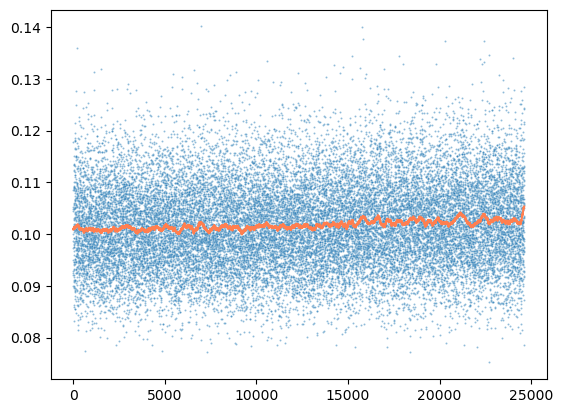

In [14]:
plot_loss(antipode_model.losses)

In [15]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Jun 16 23:55:16 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   39C    P0              38W / 250W |   5165MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

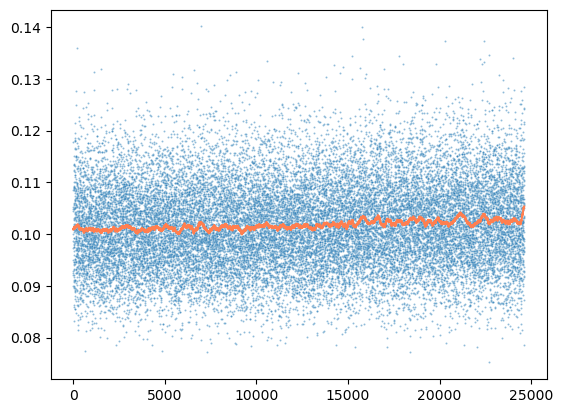

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


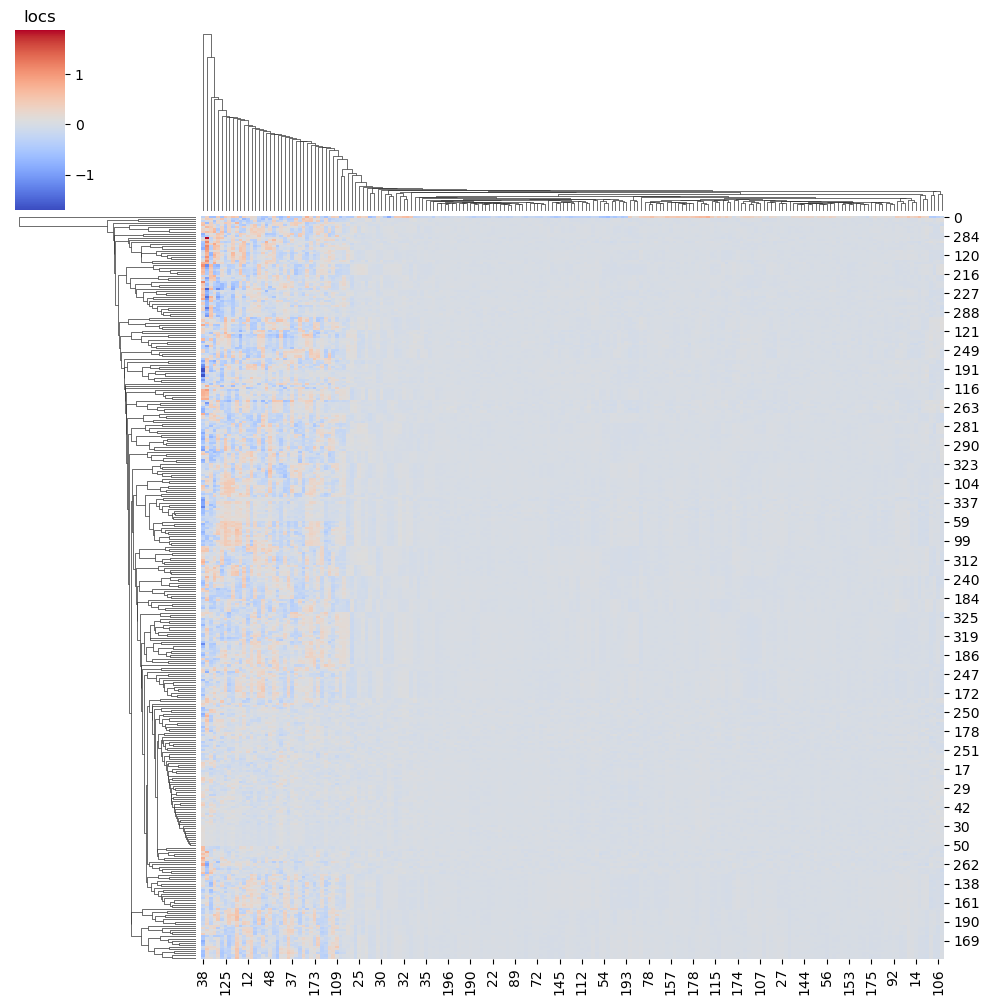

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


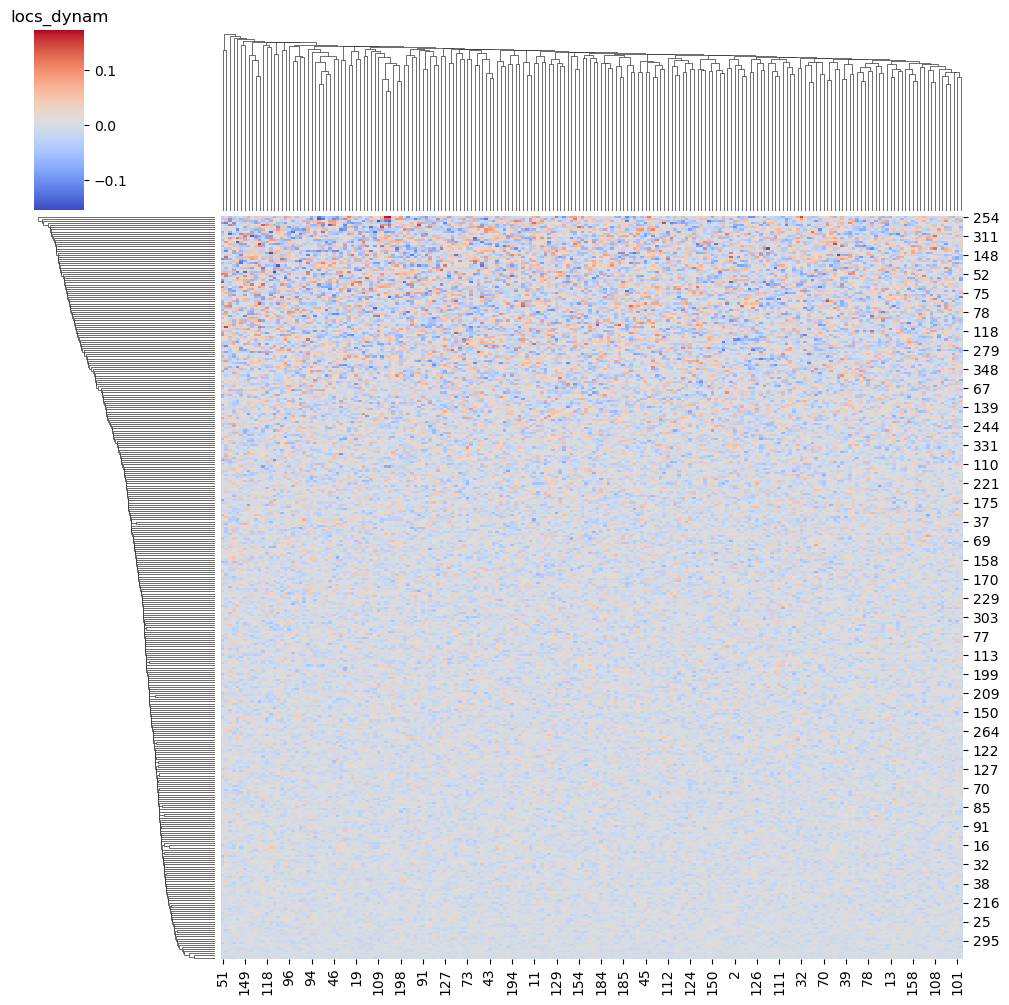

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


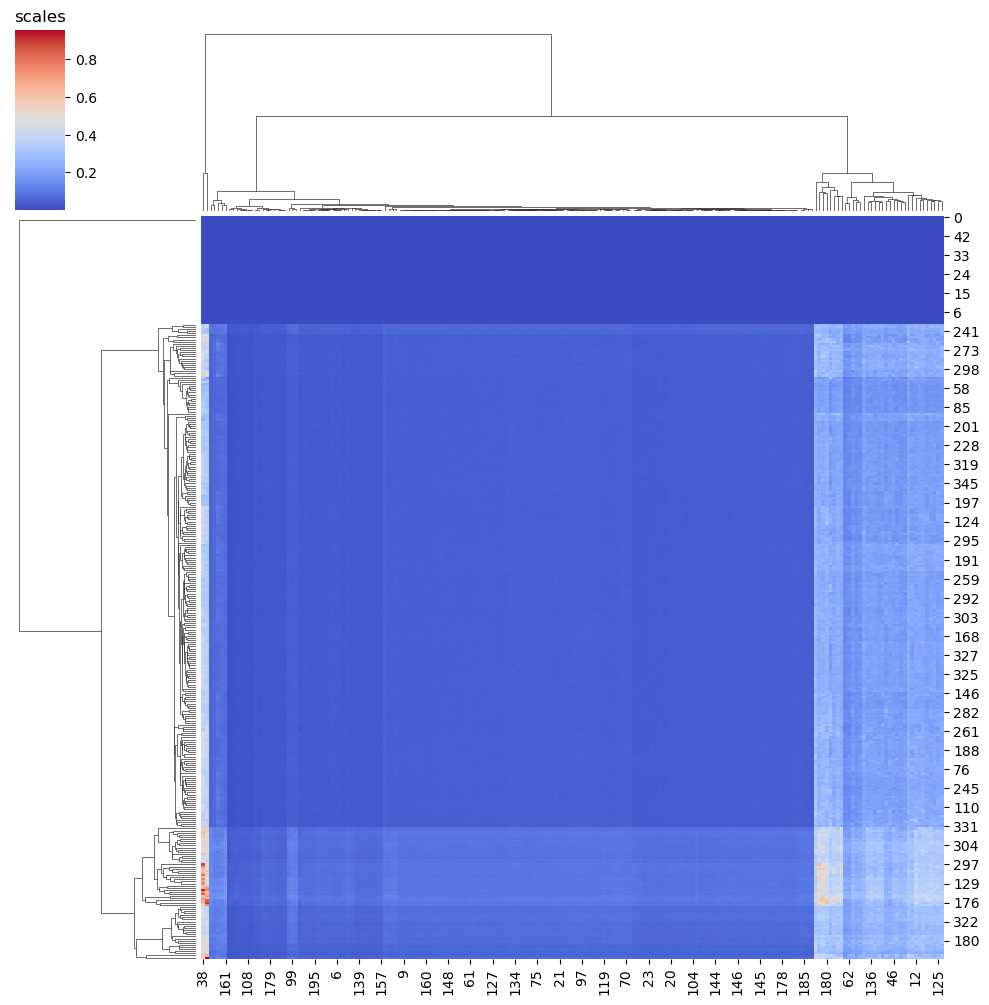

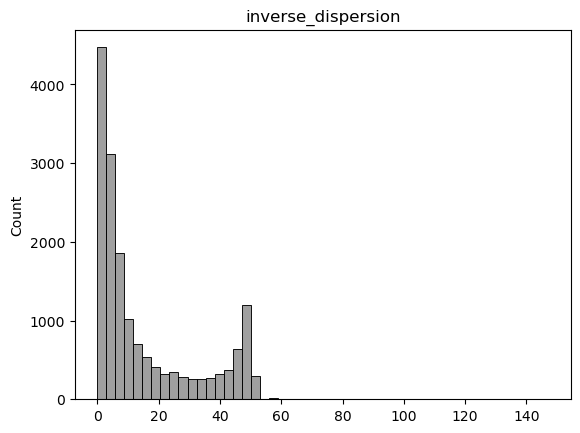

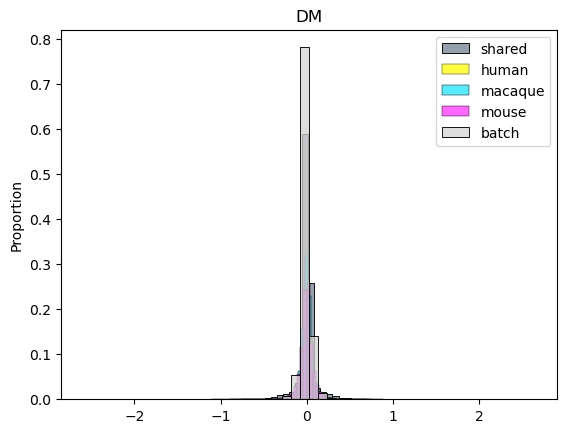

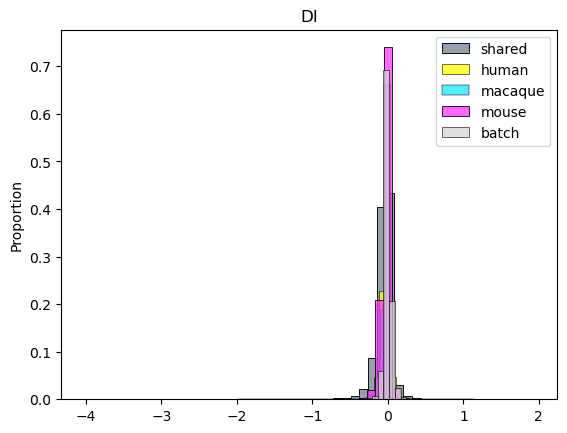

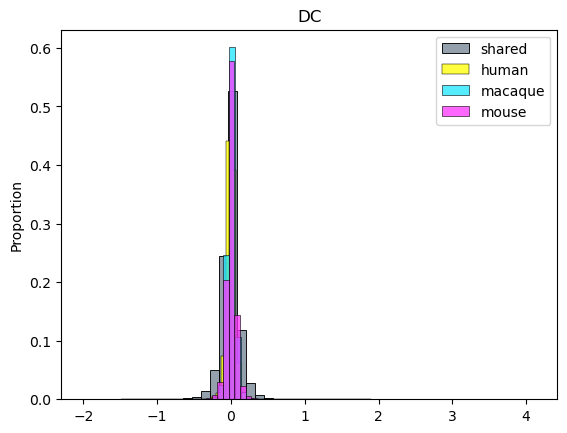

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/plotting.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_species=antipode_model.adata_manager.adata.obs.groupby(antipode_model.batch_key)['species'].value_counts().unstack().idxmax(axis=1).to_dict()


,0,1,batch_name,species
0,-0.077808,0.002592,CS12OpticVesicle_kOut,human
1,-0.051673,0.012948,CS13_anterior_midbrain_kOut,human
2,-0.050553,0.017257,CS13_central_midbrain_kOut,human
3,-0.005933,0.026575,CS13_hindbrain_kOut,human
4,-0.093850,-0.137901,CS13_olfactory_pacode_kOut,human
...,...,...,...,...
403,0.364000,0.110138,p0-WT2,mouse
404,0.279829,0.120439,p0-WT3,mouse
405,0.247970,0.011233,p0-WT4,mouse
406,0.943331,0.458195,p07_Cortex_SRR11947654,mouse


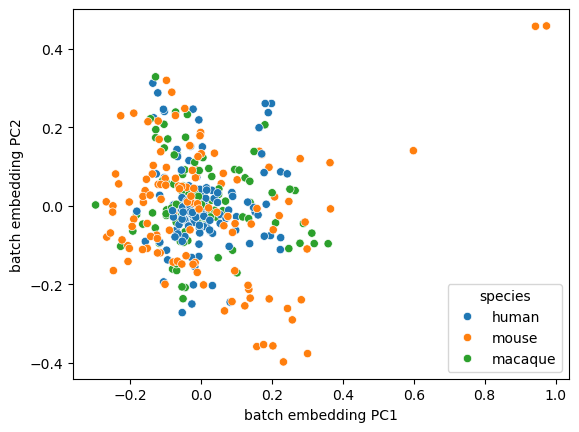

In [16]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

In [17]:
prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=(prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True)
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
discov_cluster_params=np.einsum('dpm,dmg->dpg',prop_locs+prop_discov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept+prop_discov_di+np.expand_dims(pstore['discov_constitutive_de'],1))
discov_cluster_params=discov_cluster_params

In [18]:
aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='norm_spliced')
log_real_means=np.log(aggr_means[0]+1e-3) # #species,#cluster,#genes array


100%|██████████| 693/693 [02:51<00:00,  4.03it/s]


In [19]:
real_means=pd.DataFrame(log_real_means.mean(0),columns=adata.var.index,index=aggr_means[1]['level_2'])
real_means=real_means.loc[aggr_means[1]['level_2'],:]

In [20]:
dev_cons_means=pd.DataFrame(cluster_params,columns=adata.var.index,index=cluster_labels)
dev_cons_means=dev_cons_means.loc[aggr_means[1]['level_2'],:]

In [21]:
real_dev_mouse_means=pd.DataFrame(log_real_means[2],columns=adata.var.index,index=aggr_means[1]['level_2'])
real_dev_mouse_means=real_dev_mouse_means.loc[aggr_means[1]['level_2'],:]

In [22]:
post_matched=np.log10(adata.layers['norm_spliced'][:posterior_out.shape[0]].toarray()+1.)

<Axes: >

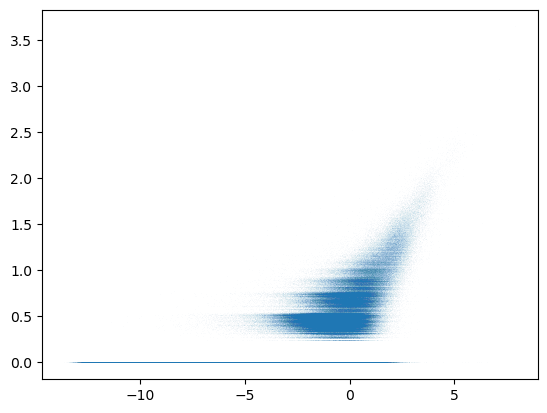

In [23]:
seaborn.scatterplot(x=posterior_out[:300,:].flatten(),y=post_matched[:300,:].flatten(),s=0.1,alpha=0.1)

<Axes: ylabel='Count'>

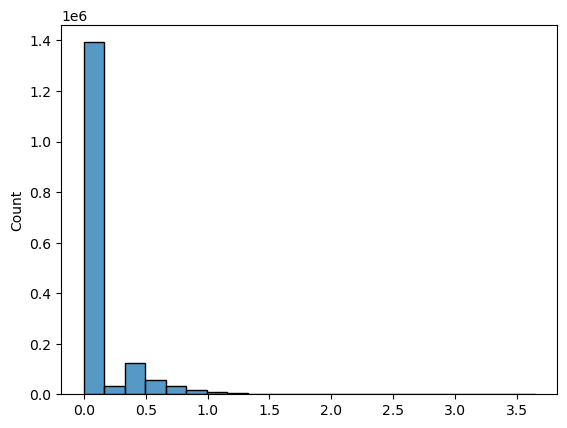

In [24]:
seaborn.histplot(post_matched[:100,:].flatten())

<Axes: ylabel='Count'>

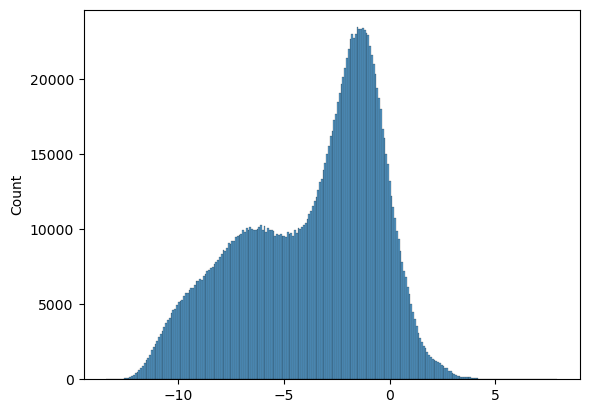

In [25]:
seaborn.histplot(posterior_out[:100,:].flatten())

In [26]:
fits=[]
for g in (range(posterior_out.shape[1])):
    x=posterior_out[:,g]
    y=post_matched[:,g]
    fits.append(scipy.stats.stats.pearsonr(x,y).statistic)


/scratch/fast/17367853/ipykernel_146552/2287017633.py:5: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  fits.append(scipy.stats.stats.pearsonr(x,y).statistic)
/home/matthew.schmitz/.local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


<Axes: >

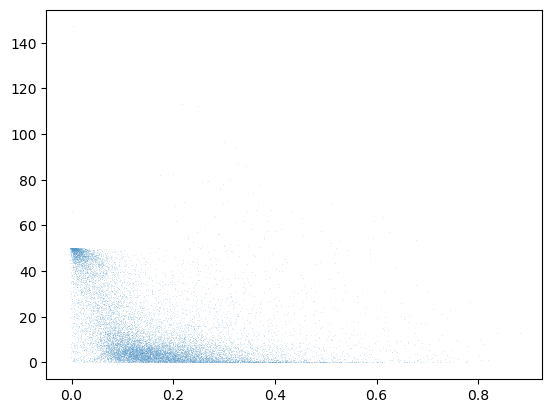

In [27]:
seaborn.scatterplot(x=fits,y=adata.uns['param_store']['s_inverse_dispersion'],s=.1)

<Axes: ylabel='None'>

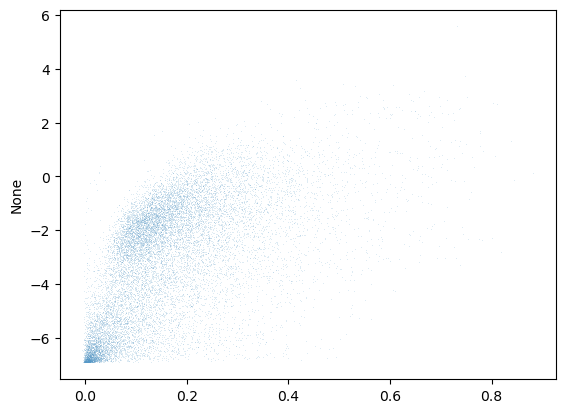

In [28]:
seaborn.scatterplot(x=fits,y=real_means.mean(0),s=.1)

<Axes: ylabel='None'>

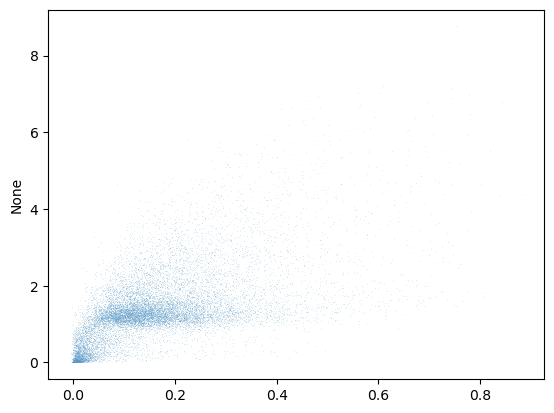

In [29]:
seaborn.scatterplot(x=fits,y=real_means.var(0),s=.1)

<Axes: xlabel='None'>

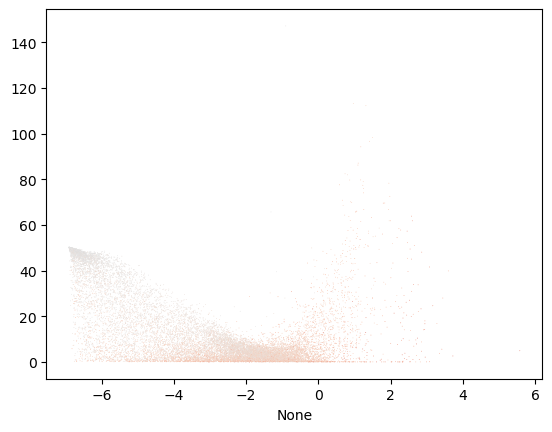

In [30]:
norm = plt.Normalize(-1, 1)

# Create a colormap object
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(norm(np.array(fits)))

seaborn.scatterplot(x=real_means.mean(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

0.15697065368272503


Text(0.5, 1.0, '')

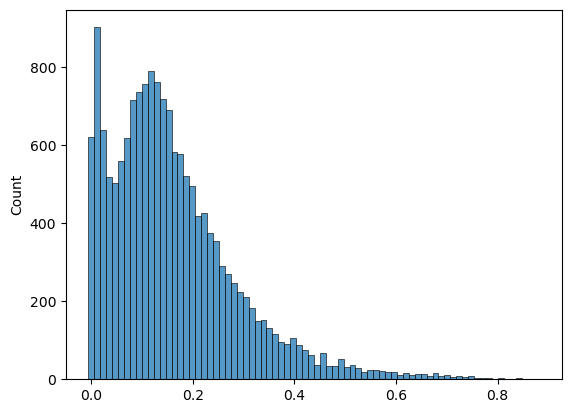

In [31]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

In [32]:
fits=[]
for g in (dev_cons_means.columns):
    x=dev_cons_means.loc[:,g]
    y=real_means.loc[:,g]
    fits.append(scipy.stats.stats.pearsonr(x,y).statistic)


/scratch/fast/17367853/ipykernel_146552/3319550554.py:5: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  fits.append(scipy.stats.stats.pearsonr(x,y).statistic)


0.3646936976972368


Text(0.5, 1.0, '')

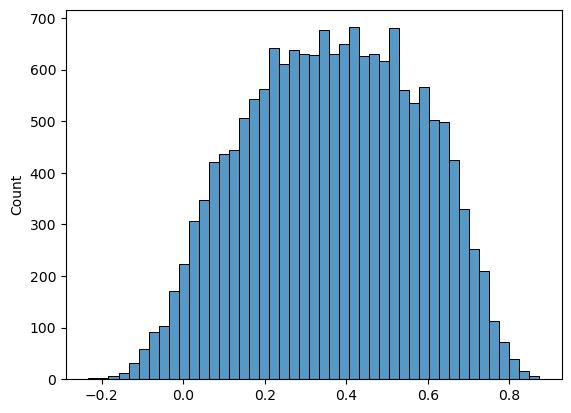

In [33]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

In [ ]:
# recon_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='reconstructed')
# recon_means=pd.DataFrame(recon_means[0].mean(0),columns=adata.var.index,index=recon_means[1]['level_2'])
# recon_means=recon_means.loc[recon_means[1]['level_2'],:]

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

In [ ]:
MDE_KEY = "X_antipode_MDE"

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color='phase',
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)
